In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import auc

pd.set_option('display.max_colwidth', None)
np.random.seed(45)

df_oct = pd.read_csv('min_distance_oct.csv', index_col=0)
df_fundus = pd.read_csv('min_distance_fundus.csv', index_col=0)
df_tabular = pd.read_csv('min_distance_tabular.csv', index_col=0)

In [2]:
def calc_sens_spec(df):
    Sens = []
    Spec = []
    t = []
    from sklearn.metrics import confusion_matrix

    for threshold in np.linspace(df['min_dist'].min()*0.95, df['min_dist'].max()*1.05, 10_000):
        df['pred'] = (df['min_dist'] < threshold).astype(int)

        tn, fp, fn, tp = confusion_matrix(df['true'], df['pred']).ravel()
        spec = tn / (tn + fp)
        sens = tp / (tp + fn)

        Sens.append(sens)
        Spec.append(spec)
        #Prec.append(prec)
        t.append(threshold)
        #F1.append(f1_score(df['true'], df['pred']))
        #Acc.append(acc)

    Sens = np.array(Sens)
    Spec = np.array(Spec)
    #Prec = np.array(Prec)
    #t = np.array(t)
    #F1 = np.array(F1)
    #Acc = np.array(Acc)
    return Sens, Spec



In [3]:
res = [calc_sens_spec(df) for df in [df_oct, df_fundus, df_tabular]]

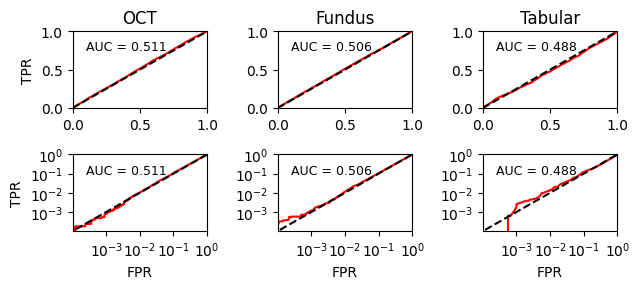

In [4]:



plt.figure(figsize=(6.5, 3))
for i, dataset in enumerate(["OCT", 'Fundus', 'Tabular']):

    Sens, Spec = res[i]
    plt.subplot(2, 3, i + 1)
    plt.title(dataset)
    plt.plot(1-Spec, Sens, color='red')
    plt.plot([0, 1], [0,1], color='black', linestyle='--')
    if i ==0:
        plt.ylabel('TPR')
    plt.xlim([0,1])
    plt.ylim([0,1])
    #plt.axis('equal')
    ax = plt.gca()
    ax.set_autoscale_on(False)
    ax.text(0.1, 0.75,f'AUC = {auc(1-Spec, Sens):.3f}', transform=ax.transAxes, fontdict={'fontsize': 9})

    plt.subplot(2, 3, i+4)
    plt.plot(1-Spec, Sens, color='red')
    plt.plot([0, 1], [0,1], color='black', linestyle='--')
    if i == 0:
        plt.ylabel('TPR')

    plt.xlabel('FPR')
    plt.xscale('log')
    plt.yscale('log')
    plt.xticks([1e-3, 1e-2, 1e-1, 1])
    plt.yticks([1e-3, 1e-2, 1e-1, 1])
    #plt.axis('equal')
    
    ax = plt.gca()
    ax.set_autoscale_on(False)
    ax.text(0.1, 0.75,f'AUC = {auc(1-Spec, Sens):.3f}', transform=ax.transAxes, fontdict={'fontsize': 9})
    ax.set_xlim([1e-4,1])
    ax.set_ylim([1e-4,1])
    

plt.tight_layout()


## Utility Measures

In [30]:
pd.read_csv('/home/nick/ai_readi_synth/tabular_generation/results.csv')

,tag,iters,data_size,seed,real_mem_auc,synth_mem_auc,elapsed_time,r2r_auc_Obesity,r2r_auc_Type 2 Diabetes,r2r_auc_Heart attack,r2r_auc_Kidney problems,r2r_auc_High blood cholesterol,r2r_auc_High blood pressure,s2r_auc_Obesity,s2r_auc_Type 2 Diabetes,s2r_auc_Heart attack,s2r_auc_Kidney problems,s2r_auc_High blood cholesterol,s2r_auc_High blood pressure
0,AI_READI,30000,0.9,0,1.0,0.535653,0,0.886808,0.985252,0.602232,0.799487,0.660037,0.736769,0.731837,0.927468,0.509757,0.604775,0.675187,0.716260
1,AI_READI,30000,0.9,1,1.0,0.536391,0,0.886807,0.985250,0.602232,0.799512,0.660027,0.736847,0.730370,0.933057,0.398390,0.652138,0.674121,0.731135
2,AI_READI,30000,0.9,2,1.0,0.534688,0,0.886806,0.985247,0.602232,0.799498,0.660043,0.736742,0.705551,0.927567,0.419322,0.586169,0.662067,0.725711
3,AI_READI,30000,0.9,3,1.0,0.535215,0,0.886806,0.985252,0.602232,0.799479,0.660024,0.736843,0.723328,0.931319,0.440641,0.620141,0.673666,0.735590
4,AI_READI,30000,0.9,4,1.0,0.532375,0,0.886807,0.985244,0.602232,0.799488,0.660028,0.736824,0.739679,0.927921,0.456852,0.596156,0.672431,0.730444


In [31]:
tabular = pd.read_csv('/home/nick/ai_readi_synth/tabular_generation/results.csv')
tab_cols = ['T2DM', 'High Chol.', 'High BP']
renaming = {
    's2r_auc_Type 2 Diabetes':'s2r_auc T2DM', 
    'r2r_auc_Type 2 Diabetes': 'r2r_auc T2DM',
    's2r_auc_High blood cholesterol':'s2r_auc High Chol.', 
    'r2r_auc_High blood cholesterol': 'r2r_auc High Chol.',
    's2r_auc_High blood pressure':'s2r_auc High BP', 
    'r2r_auc_High blood pressure': 'r2r_auc High BP',
}

tabular = tabular[list(renaming.keys())].rename(columns=renaming)

#tabular = pd.DataFrame(tabular.mean().astype(str).apply(lambda x: x[0:5]) + ' ± ' + tabular.std().astype(str).apply(lambda x: x[0:5]))
#tabular.index = ['Synthetic', 'Real']
#tabular.columns = ['Tabular']


In [32]:
import os 
df = {
    'modality': [],
    'val_loss': [],
    'train': [],
    'test': [],
    'roc_auc_AMD': [],
    'roc_auc_GL': [],
    'roc_auc_DR': []
}
for folder in os.listdir('/home/nick/ai_readi_synth/classification/RETFound_MAE/output_dir'):
    temp = folder.split('_')

    if len(temp) == 3: 
        df['train'].append('real')
        df['test'].append('real')
    elif len(temp) == 4:
        #print(temp[2][0])
        df['train'].append('synth' if temp[2][0] == 's' else 'real')
        df['test'].append('synth' if '2' in temp[2] else 'real')

    df['modality'].append(temp[1])
    #print(temp)
    res = pd.read_csv('/home/nick/ai_readi_synth/classification/RETFound_MAE/output_dir/{}/metrics_test.csv'.format(folder), index_col=None)
    for col in res.iloc[-1].index:
        df[col].append(res.iloc[-1][col])
    
df = pd.DataFrame(df)
df['label'] = df['train'] + '-to-' + df['test']

df = df.rename(columns={'roc_auc_AMD':'AMD', 'roc_auc_GL':'GL', 'roc_auc_DR':'DR'})

In [33]:
temp_df = df.iloc[0:0,:].copy()
AUCs = {x:[] for x in tab_cols}
for i, row in tabular.iterrows():
    temp_df = pd.concat([temp_df, pd.DataFrame([['tabular', np.nan, 'synth', 'real', np.nan, np.nan, np.nan, 'synth-to-real']], columns=temp_df.columns)])
    temp_df = pd.concat([temp_df, pd.DataFrame([['tabular', np.nan, 'real', 'real', np.nan, np.nan, np.nan, 'real-to-real']], columns=temp_df.columns)])

    for col in tab_cols:
        AUCs[col].append(row.loc['s2r_auc ' + col])
        AUCs[col].append(row.loc['r2r_auc ' + col])

for col in tab_cols:
    temp_df[col] = AUCs[col]

df = pd.concat([df, temp_df])

df['modality'] = df['modality'].apply(lambda x: 'OCT' if x == 'oct' else x[0].upper() + x[1:])

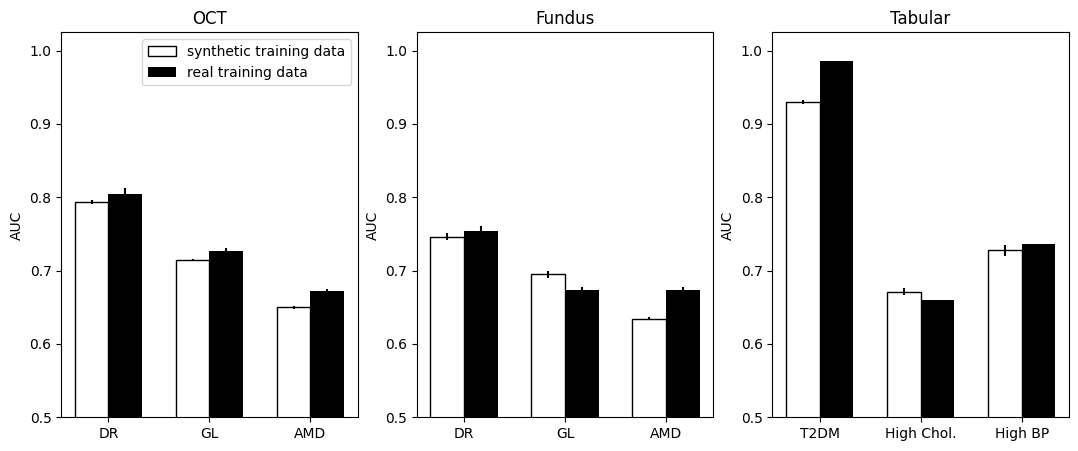

In [34]:
# Performance on real test data
def bar_results(df, modality):

    if modality == 'Tabular':
        tasks = tab_cols
    else:
        tasks = ['DR', 'GL', 'AMD']

    width = 0.5
    counter = 0
    temp = df[df['modality'] == modality].set_index('label').loc[[f'synth-to-real', f'real-to-real']]
    for task in tasks:
        labs = ['synthetic training data','real training data'] if modality == 'OCT' and task == 'DR' else [None, None]
        plt.bar(counter, temp.loc['synth-to-real'][task].mean(), width=width, color='white', label=labs[0], yerr=temp.loc['synth-to-real'][task].std(), edgecolor='black')
        plt.bar(counter+width, temp.loc['real-to-real'][task].mean(), width=width, color='black', label=labs[1], yerr=temp.loc['real-to-real'][task].std())

        counter += 1+width
        
    
    plt.xticks(np.linspace(width/2, len(tasks) + width/2, len(tasks)), tasks)

    if modality == 'OCT':
        plt.legend()

    plt.title(modality)
    plt.ylabel("AUC")
    plt.ylim([0.5, 1.025])


#
fig, axs = plt.subplots(
    1,3,
    figsize=(13,5),
    width_ratios=[3, 3, 3],
)

plt.subplot(1,3,1)
bar_results(df, 'OCT')

plt.subplot(1,3,2)
bar_results(df, 'Fundus')

plt.subplot(1,3,3)
bar_results(df, 'Tabular')

## Fidelity Figures

In [11]:
synth = pd.read_csv('/data/7TB/nick/ai_readi_v3/tabular_processed_data/synthetic_rescaled.csv', index_col=0).drop(columns=['Dementia/Alzheimers'])
real = pd.read_csv('/data/7TB/nick/ai_readi_v3/tabular_processed_data/original_training_data.csv').drop(columns=['Dementia/Alzheimers'])


/home/nick/.local/lib/python3.13/site-packages/pandas/core/internals/blocks.py:395: RuntimeWarning: invalid value encountered in log
  result = func(self.values, **kwargs)


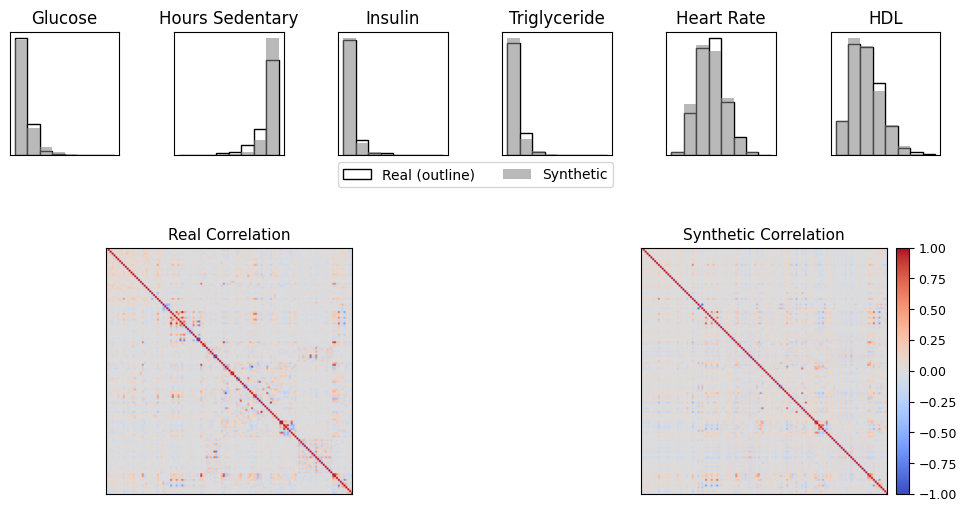

In [12]:
def make_histogram(real, synth, ax, col, color, title):
    
    bins = ax.hist(real[col], edgecolor='black', color='white', density=True, bins=8, label='Real (outline)')
    ax.hist(synth[col], color=color, alpha=0.55, density=True, bins=bins[1], label='Synthetic')
    #ax.text(0.35, 0.6, f'AWD = {ad2d:.2f}', transform=ax.transAxes, fontsize=13)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_title(title)
    return

import seaborn as sns
from numpy.linalg import norm
def plot_mat(mat, title, ax):
    im = ax.imshow(mat, cmap="coolwarm", vmin=-1, vmax=1)
    ax.set_title(title, fontsize=11, pad=6)
    ax.set_xticks([])
    ax.set_yticks([])
    return im

colmap = {'Glucose [Mass/volume] in Serum or_value (mg/dL)': 'Glucose', 
          'act_sedentary_hrs': 'Hours Sedentary', 
          'Insulin [Units/volume] in Serum o_value (ng/L)': 'Insulin', 
          'Triglyceride [Mass/volume] _value (mg/dL)': 'Triglyceride', 
          'Rate': 'Heart Rate',
          'Cholesterol in HDL [Mass/_value (mg/dL)': 'HDL'
        }

fig, axs = plt.subplots(2, 6, figsize = (12, 6),  height_ratios=[1,2])


colors = ['gray']*6#['blue', 'green', 'red', 'orange', 'purple', 'gray']

for i, col in enumerate(colmap.keys()):
        
    make_histogram(real, synth, axs[0, i], col=col, color=colors[i], title=colmap[col])
    if i == 3:
        axs[0,i].legend(ncols=2, bbox_to_anchor=[1.075,0])
    x_min, x_max = float('inf'), float('-inf')
    y_min, y_max = float('inf'), float('-inf')
    
    current_xlim = ax.get_xlim()
    current_ylim = ax.get_ylim()
    
    # Update global limits
    x_min = min(x_min, current_xlim[0])
    x_max = max(x_max, current_xlim[1])
    y_min = min(y_min, current_ylim[0])
    y_max = max(y_max, current_ylim[1])

    ax.set_xlim(x_min, x_max)
    ax.set_ylim(y_min, y_max)




cols = real.columns
real_corr = real[cols].corr()
syn_corr  = synth[cols].corr().fillna(0)
diff_corr = np.log(syn_corr / real_corr)

n = real_corr.shape[1]


#for ax, corr, title in zip(axes, (real_corr, syn_corr, diff_corr), ("Real correlation", "Synthetic correlation", 'Log Ratio')):
#    im = plot_mat(corr, title)


gs = axs[1, 5].get_gridspec()
for ax in axs[1, 0:3]:
    ax.remove()
axbig = fig.add_subplot(gs[1, 0:3]) 
im = plot_mat(real_corr, 'Real Correlation', axbig)




gs = axs[1, 5].get_gridspec()
# remove the underlying Axes
for ax in axs[1, -3:]:
    ax.remove()
axbig = fig.add_subplot(gs[1, -3:]) 
im = plot_mat(syn_corr, 'Synthetic Correlation', axbig)
fig.colorbar(im, ax=axbig, orientation="vertical", fraction=0.1, pad=0.02).ax.tick_params(labelsize=9)


fig.subplots_adjust(hspace=0.5, wspace=0.5) # Adjust vertical and horizontal space

    



## Demo Images

In [13]:

path = '/data/7TB/nick/synth_ai_readi_fundus/retinal_photography/'

df = pd.read_csv(path+'manifest.tsv', delimiter='\t', index_col=0)

# Read in clinical data
obs = pd.read_csv("/".join(path.split('/')[0:-2]) + '/clinical_data/observation.csv', index_col=None)
person = obs[['person_id']].iloc[0:len(obs)//3]

# Identify people who have these opthalmologic conditions
codes = {'AMD': 374028, 'DR':4174977, 'GL': 437541}

for condition in ['AMD', 'DR', 'GL']:
    code = codes[condition]
    person = pd.merge(person, obs[obs['qualifier_concept_id'] == code][['person_id', 'value_as_number']].rename(columns={'value_as_number': condition}), on='person_id', how='right')#.values
    
# Create split
person['recommended_split'] = pd.cut(range(len(person)), bins=[0, 0.8*len(person), 0.9*len(person), len(person)], labels=['train', 'val', 'test'], right=False)

# Merge clinical + demographic with image-level data
df = pd.merge(df, person.rename(columns={'person_id': 'participant_id'}), how='inner', on='participant_id')


In [14]:
import pydicom
from PIL import Image
from torchvision.utils import make_grid
import torch
import torchvision.transforms as transforms

np.random.seed(42)
imgs = df.groupby(['manufacturers_model_name']).sample(10).sample(frac=1.0).iloc[:6]
cfp = make_grid([transforms.ToTensor()(pydicom.dcmread('/data/7TB/nick/synth_ai_readi_fundus/' + i['filepath']).pixel_array) for n, i in imgs.iterrows()], nrow=6)
cfp = transforms.ToPILImage()(cfp).convert("RGB")

In [15]:

path = '/data/7TB/nick/synth_ai_readi_oct/retinal_oct/'

df = pd.read_csv(path+'manifest.tsv', delimiter='\t', index_col=0)

# Read in clinical data
obs = pd.read_csv("/".join(path.split('/')[0:-2]) + '/clinical_data/observation.csv', index_col=None)
person = obs[['person_id']].iloc[0:len(obs)//3]

# Identify people who have these opthalmologic conditions
codes = {'AMD': 374028, 'DR':4174977, 'GL': 437541}

for condition in ['AMD', 'DR', 'GL']:
    code = codes[condition]
    person = pd.merge(person, obs[obs['qualifier_concept_id'] == code][['person_id', 'value_as_number']].rename(columns={'value_as_number': condition}), on='person_id', how='right')#.values
    
# Create split
person['recommended_split'] = pd.cut(range(len(person)), bins=[0, 0.8*len(person), 0.9*len(person), len(person)], labels=['train', 'val', 'test'], right=False)

# Merge clinical + demographic with image-level data
df = pd.merge(df, person.rename(columns={'person_id': 'participant_id'}), how='inner', on='participant_id')

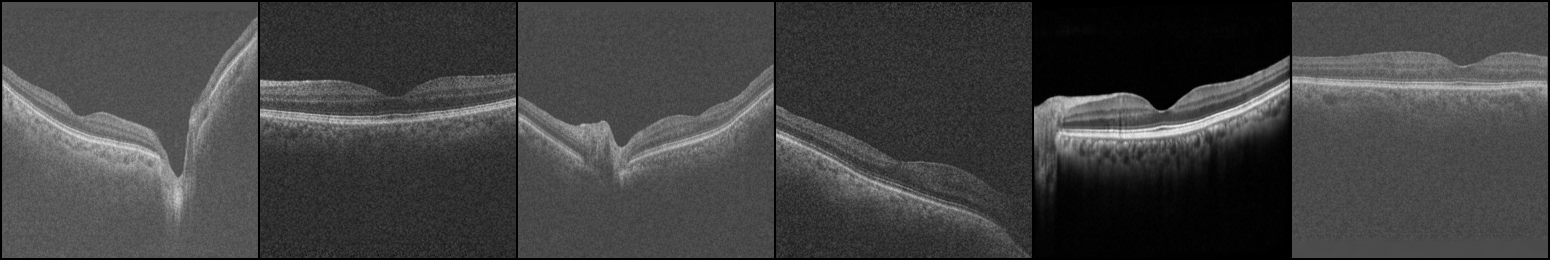

In [27]:
import pydicom
from PIL import Image
from torchvision.utils import make_grid
import torch
import torchvision.transforms as transforms

np.random.seed(42)
imgs = df.groupby(['manufacturers_model_name']).sample(9).sample(frac=1.0).iloc[0:6]
oct = make_grid([transforms.ToTensor()(pydicom.dcmread('/data/7TB/nick/synth_ai_readi_oct/' + i['filepath']).pixel_array) for n, i in imgs.iterrows()], nrow=6)
oct = transforms.ToPILImage()(oct).convert("RGB").resize((1550, 260), Image.LANCZOS)
oct

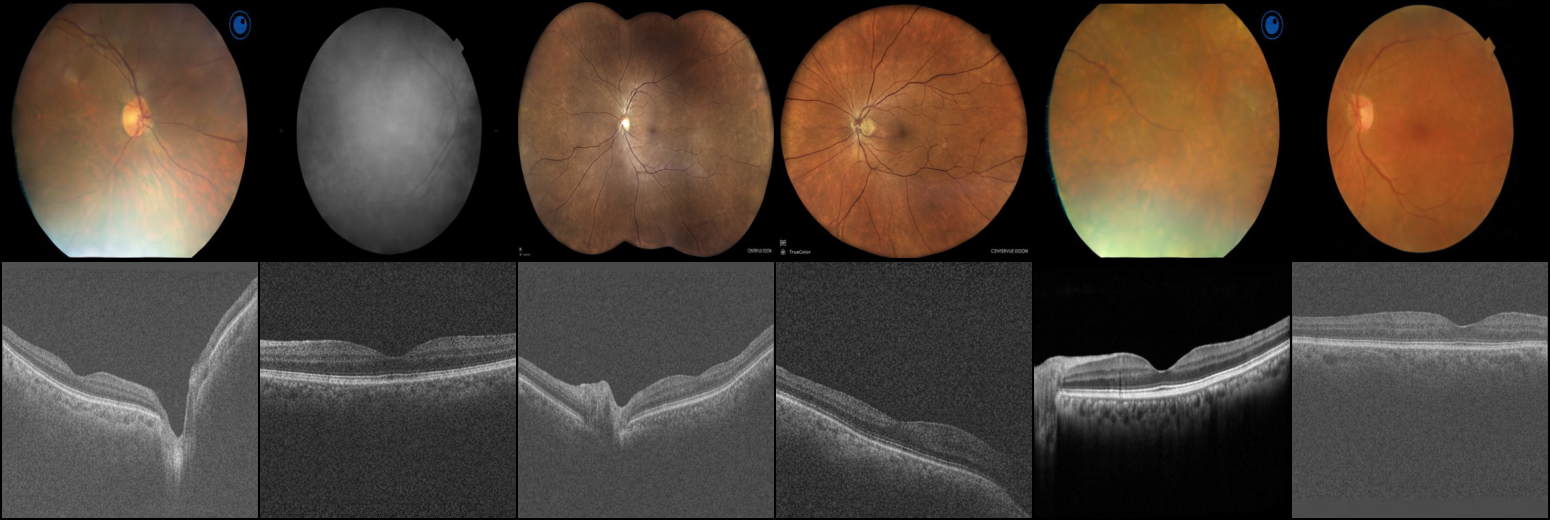

In [28]:
def concat(images):

    # Determine the dimensions of the new image
    width = max(img.width for img in images)
    height = sum(img.height for img in images)

    # Create a new blank image
    # Use 'RGBA' to support transparency if needed, otherwise 'RGB'
    new_image = Image.new('RGBA', (width, height), (255, 255, 255, 255)) # White background

    y_offset = 0
    for img in images:
        new_image.paste(img, (0, y_offset))
        y_offset += img.height

    return new_image

concat([cfp, oct])